In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

import pybaseball

print("Environment ready")

Environment ready


In [2]:
from pybaseball import batting_stats

In [4]:
raw_data = batting_stats(2019, 2025)

In [5]:
raw_data.columns

Index(['IDfg', 'Season', 'Name', 'Team', 'Age', 'G', 'AB', 'PA', 'H', '1B',
       ...
       'maxEV', 'HardHit', 'HardHit%', 'Events', 'CStr%', 'CSW%', 'xBA',
       'xSLG', 'xwOBA', 'L-WAR'],
      dtype='str', length=320)

In [6]:
# for i in raw_data.columns:
# print(i)

In [7]:
batting_data = raw_data[
    [
        "Season",
        "Name",
        "Team",
        "Age",
        "G",
        "AB",
        "PA",
        "AVG",
        "OBP",
        "SLG",
        "OPS",
        "Barrel%",
        "HardHit%",
        "xBA",
        "xSLG",
    ]
]
batting_data.head()

,Season,Name,Team,Age,G,AB,PA,AVG,OBP,SLG,OPS,Barrel%,HardHit%,xBA,xSLG
1,2024,Aaron Judge,NYY,32,158,559,704,0.322,0.458,0.701,1.159,0.269,0.611,0.305,0.740
3,2022,Aaron Judge,NYY,30,157,570,696,0.311,0.425,0.686,1.111,0.262,0.611,0.304,0.732
33,2024,Bobby Witt Jr.,KCR,24,161,636,709,0.332,0.389,0.588,0.977,0.143,0.483,0.309,0.583
2,2025,Aaron Judge,NYY,33,152,541,679,0.331,0.457,0.688,1.144,0.247,0.582,0.300,0.708
12,2023,Ronald Acuna Jr.,ATL,25,159,643,735,0.337,0.416,0.596,1.012,0.153,0.552,0.351,0.668


COLUMN NAMES
Season - Season
Name - Player name
Team - Team player plays for
Age - Players age during season?
G - Games played
AB - At Bats
PA - Plate Appearances
**AVG - Average 
OBP - On base percentage
SLG - Slugging percentage
OPS - On Base + Slugging
Barrel% - 

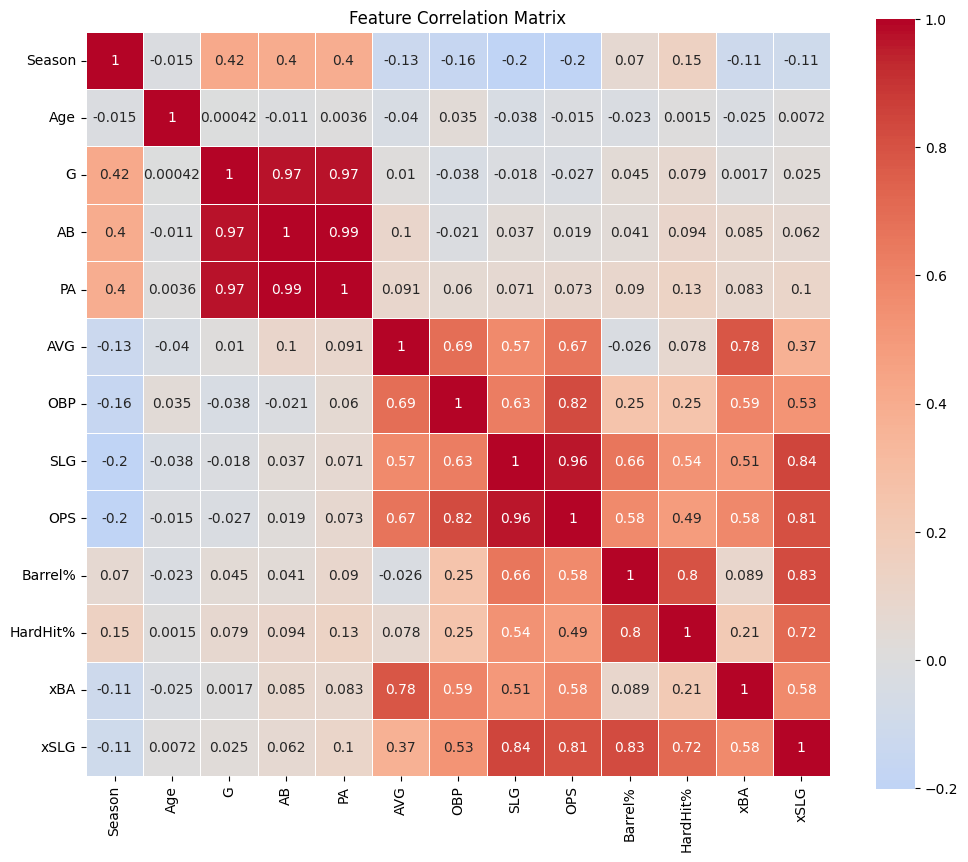

In [13]:
# visualizing correlation

corr = batting_data.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(corr, cmap="coolwarm", center=0, square=True, annot=True, linewidths=0.5)

plt.title("Feature Correlation Matrix")
plt.show()

In [17]:
# removing columns we probably don't want

batting_data_2 = raw_data[
    ["Season", "Name", "Team", "Age", "PA", "AVG", "OBP", "SLG", "Barrel%", "HardHit%"]
]
batting_data_2.head()

,Season,Name,Team,Age,PA,AVG,OBP,SLG,Barrel%,HardHit%
1,2024,Aaron Judge,NYY,32,704,0.322,0.458,0.701,0.269,0.611
3,2022,Aaron Judge,NYY,30,696,0.311,0.425,0.686,0.262,0.611
33,2024,Bobby Witt Jr.,KCR,24,709,0.332,0.389,0.588,0.143,0.483
2,2025,Aaron Judge,NYY,33,679,0.331,0.457,0.688,0.247,0.582
12,2023,Ronald Acuna Jr.,ATL,25,735,0.337,0.416,0.596,0.153,0.552


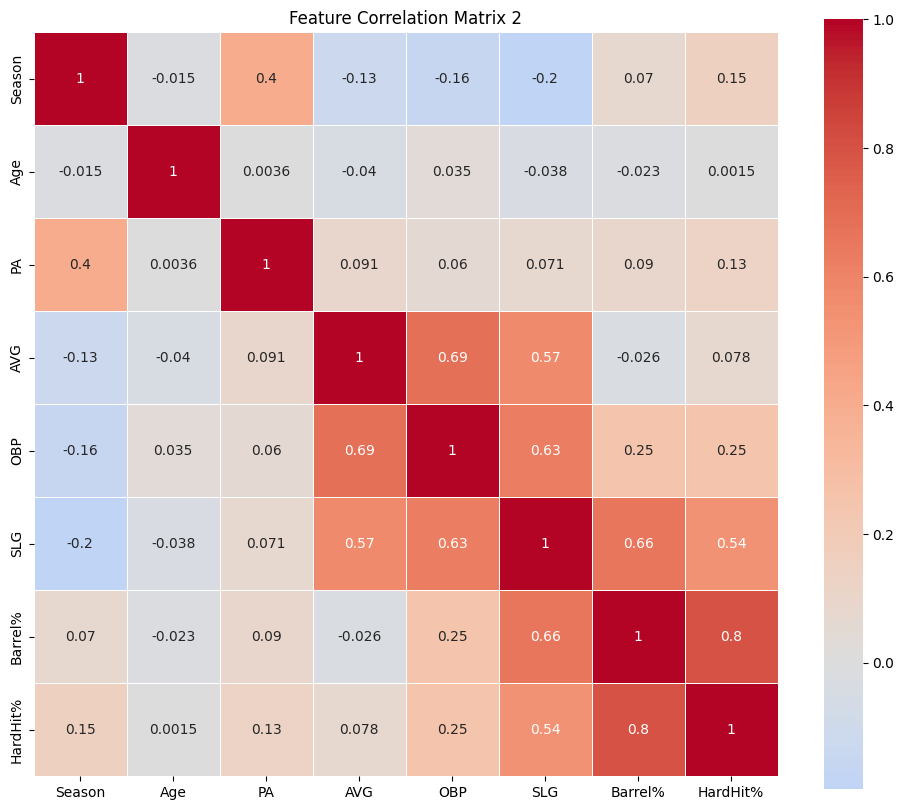

In [18]:
# visualizing again

corr_2 = batting_data_2.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(corr_2, cmap="coolwarm", center=0, square=True, annot=True, linewidths=0.5)

plt.title("Feature Correlation Matrix 2")
plt.show()

<Figure size 1200x1000 with 0 Axes>

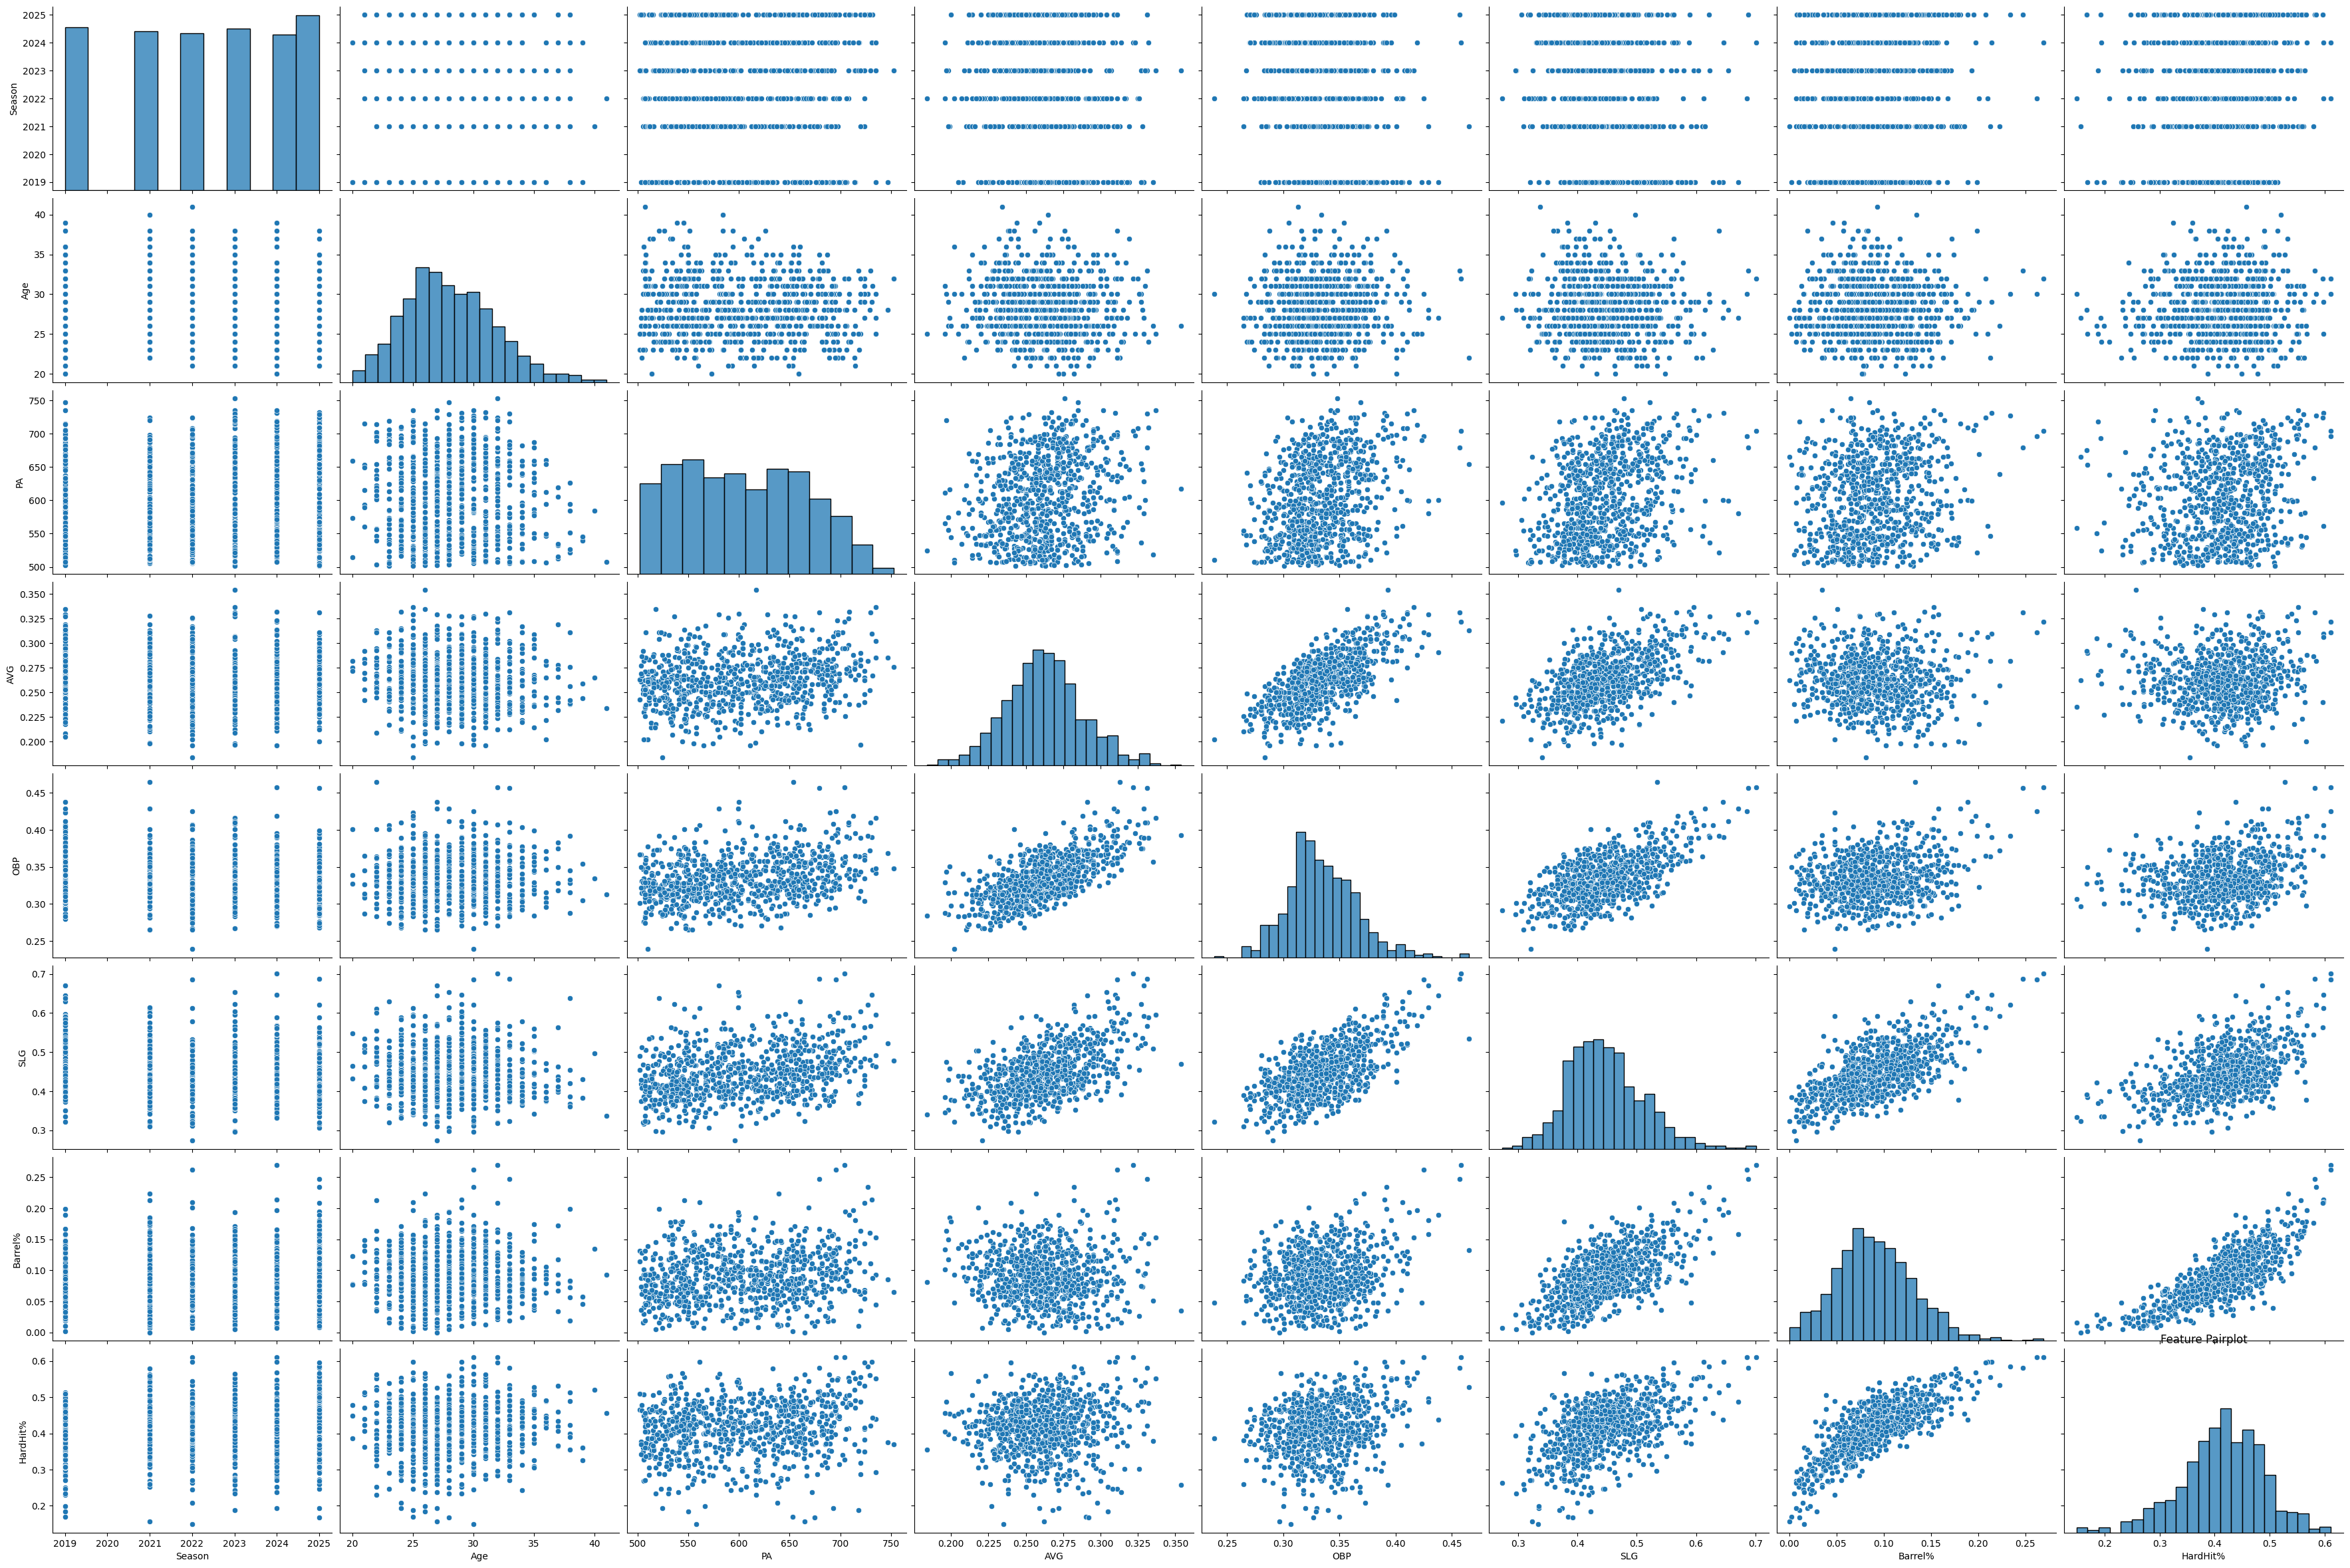

In [23]:
# visualizing relationships and distributions

plt.figure(figsize=(12, 10))

sns.pairplot(batting_data_2, height=3, aspect=1.5)

plt.title("Feature Pairplot")
plt.show()

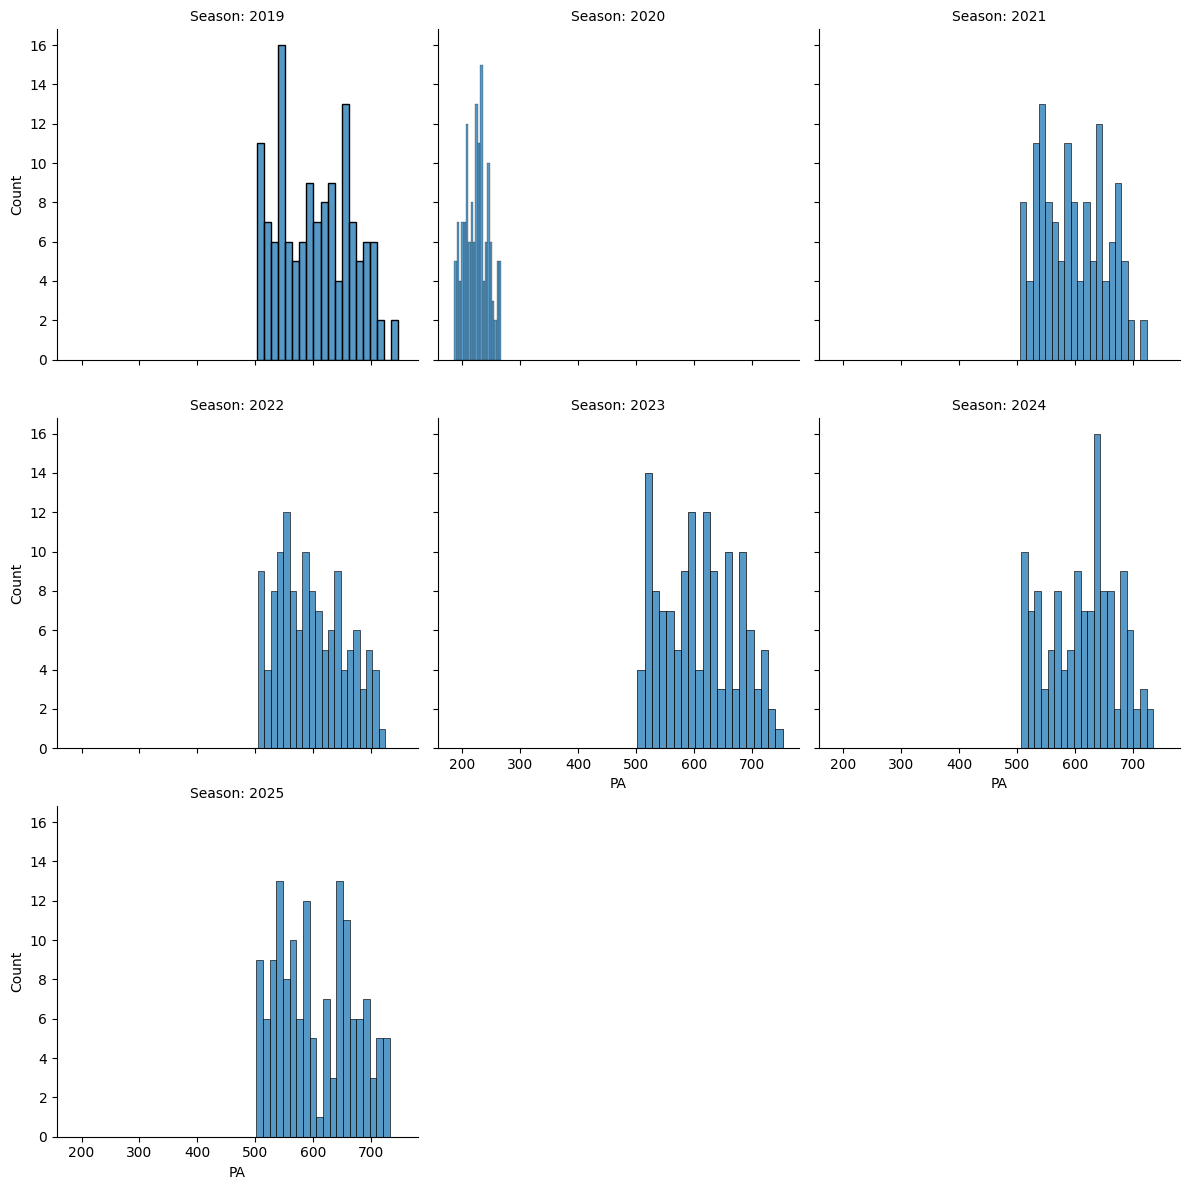

In [21]:
# investigating why PA is split awkwardly

g = sns.FacetGrid(batting_data_2, col="Season", col_wrap=3, height=4)
g.map_dataframe(sns.histplot, x="PA", bins=20)
g.set_axis_labels("PA", "Count")
g.set_titles("Season: {col_name}")
plt.show()

In [22]:
# looks like they restricted the dataset to players with 500 PA each season
# the 2020 covid season messed that up, there were many with <500
# we will remove the 2020 season as all instances could be considered outliers

batting_data_2 = batting_data_2[batting_data_2["Season"] != 2020]

<Figure size 1200x1000 with 0 Axes>

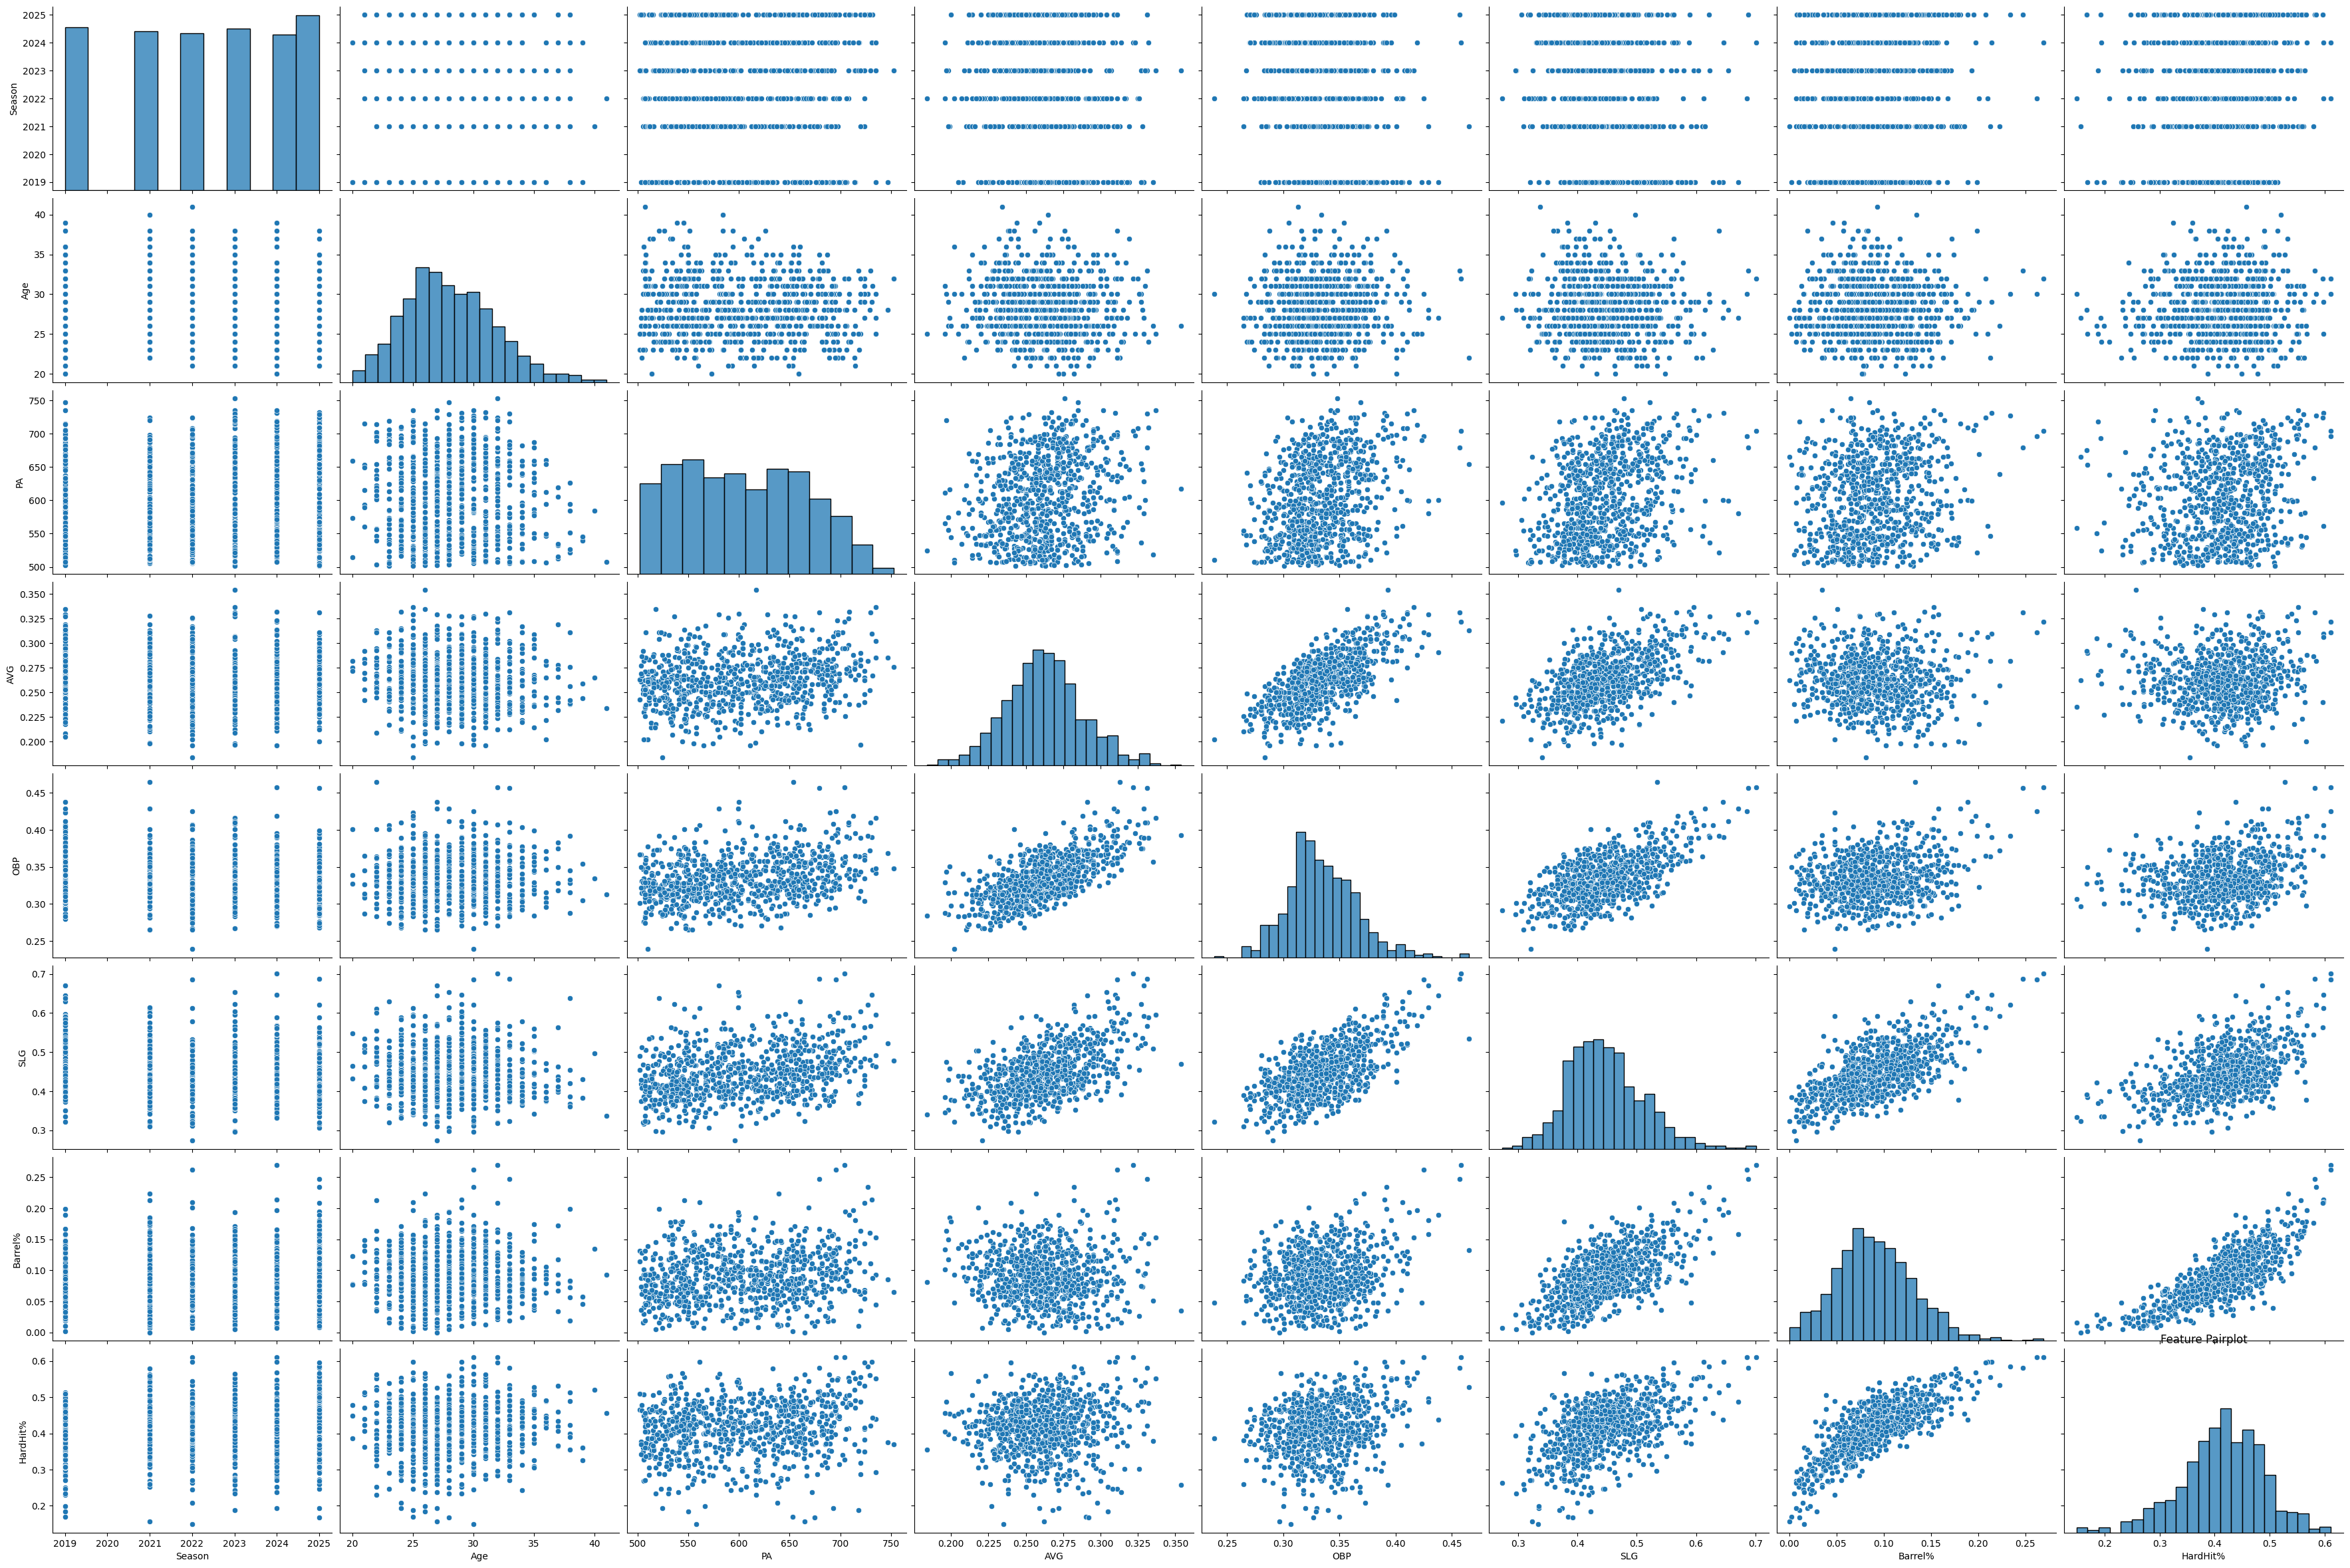

In [24]:
plt.figure(figsize=(12, 10))

sns.pairplot(batting_data_2, height=3, aspect=1.5)

plt.title("Feature Pairplot")
plt.show()

In [30]:
print("Shape: ", batting_data_2.shape)
print(batting_data_2.info())

Shape:  (805, 10)
<class 'pandas.DataFrame'>
Index: 805 entries, 1 to 813
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Season    805 non-null    int64  
 1   Name      805 non-null    str    
 2   Team      805 non-null    str    
 3   Age       805 non-null    int64  
 4   PA        805 non-null    int64  
 5   AVG       805 non-null    float64
 6   OBP       805 non-null    float64
 7   SLG       805 non-null    float64
 8   Barrel%   805 non-null    float64
 9   HardHit%  805 non-null    float64
dtypes: float64(5), int64(3), str(2)
memory usage: 82.0 KB
Info:  None


We will want to remember that some players may have had 500 PA's in some seasons and less in others.So they may appear in the dataset for some seasons and not for others. This has the potential to harm our analysis - but I am not sure if it will or not

In [35]:
# Count number of seasons per player
player_counts = batting_data_2["Name"].value_counts()

# Keep players with 6 or more seasons
eligible_players = player_counts[player_counts >= 6].index

In [36]:
df_filtered = batting_data_2[batting_data_2["Name"].isin(eligible_players)].copy()

df_filtered["Name"].value_counts()

Name
Juan Soto                6
Freddie Freeman          6
Francisco Lindor         6
Mookie Betts             6
Trea Turner              6
Manny Machado            6
Paul Goldschmidt         6
Matt Olson               6
Dansby Swanson           6
Rafael Devers            6
Marcus Semien            6
Jose Ramirez             6
Vladimir Guerrero Jr.    6
Bryan Reynolds           6
Matt Chapman             6
Willy Adames             6
Pete Alonso              6
Eugenio Suarez           6
Nick Castellanos         6
Gleyber Torres           6
Josh Bell                6
Ryan McMahon             6
Name: count, dtype: int64

In [37]:
print("Shape: ", df_filtered.shape)
print(df_filtered.info())

Shape:  (132, 10)
<class 'pandas.DataFrame'>
Index: 132 entries, 14 to 841
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Season    132 non-null    int64  
 1   Name      132 non-null    str    
 2   Team      132 non-null    str    
 3   Age       132 non-null    int64  
 4   PA        132 non-null    int64  
 5   AVG       132 non-null    float64
 6   OBP       132 non-null    float64
 7   SLG       132 non-null    float64
 8   Barrel%   132 non-null    float64
 9   HardHit%  132 non-null    float64
dtypes: float64(5), int64(3), str(2)
memory usage: 13.5 KB
None


Removing players that did not have 500 PA's in EVERY season dropped our number of rows from 805 to 132